# Experimento CN-only con Variables Demográficas

Entrenar el modelo exclusivamente en controles sanos (CN), incluyendo educación y sitio como features adicionales. Evaluar brain age gap en poblaciones clínicas (AD, FTD).

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
if (_cwd / "src").exists():
    ROOT = _cwd
elif (_cwd.parent / "src").exists():
    ROOT = _cwd.parent
else:
    raise RuntimeError(f"Cannot locate project root from {_cwd}")

REPO = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Code root:", ROOT)
print("Repo root:", REPO)

Code root: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Code
Repo root: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import optuna

from src.config import Paths, ExperimentConfig
from src.cohort import build_final_cohort_df
from src.data_io import read_full_metadata
from src.splits import load_splits
from src.utils_ids import normalize_record_id
from src.figures import readable_feature_name

paths = Paths(
    excel_path=REPO / "Data" / "datos-redlat.xlsx",
    fc_folder=REPO / "Data" / "fc_mats",
    t1w_csv_path=REPO / "Data" / "Redlat_VGM_AAL_.csv",
    out_dir=REPO / "Outputs",
)
cfg = ExperimentConfig(seed=42)
np.random.seed(cfg.seed)

OUTDIR = paths.out_dir / "experiments" / "cn_demographics"
OUTDIR.mkdir(parents=True, exist_ok=True)
IMGDIR = REPO / "Latex" / "06_resultados_discusion" / "images"
IMGDIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 11, "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
})

/home/nico/Desktop/5to/TesisFinal/.tesis-final-venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-26 19:15:42.289835: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 19:15:42.324257: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 19:15:43.341697: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
cohort = build_final_cohort_df(
    excel_path=paths.excel_path,
    fc_folder=paths.fc_folder,
    t1w_csv_path=paths.t1w_csv_path,
    diagnoses_to_use=cfg.diagnoses_to_use,
)

splits = load_splits(paths.out_dir / "splits" / "splits_seed42_test0.1.json")
trainval_ids = splits["holdout"]["trainval_ids"]
test_ids = splits["holdout"]["test_ids"]

Z_trainval = np.load(paths.out_dir / "embeddings" / "mu_trainval.npy")
Z_test = np.load(paths.out_dir / "embeddings" / "mu_test.npy")

with open(paths.out_dir / "embeddings" / "mu_trainval.json") as f:
    emb_tv_meta = json.load(f)
with open(paths.out_dir / "embeddings" / "mu_test.json") as f:
    emb_te_meta = json.load(f)

emb_tv_ids = emb_tv_meta["ids"]
emb_te_ids = emb_te_meta["ids"]

full_meta = read_full_metadata(paths.excel_path)
demo = full_meta[["record_id", "site", "cog_ed"]].copy()
merged = cohort[["record_id", "age", "sex", "diagnosis"]].merge(demo, on="record_id", how="left")

print(f"Cohort: {len(cohort)}, Trainval: {len(trainval_ids)}, Test: {len(test_ids)}")

Cohort: 1245, Trainval: 1120, Test: 125


## Build CN-only dataset with demographics

In [4]:
t1_cols = [c for c in cohort.columns if c.startswith("t1_")]

def build_features(ids_list, Z_array, emb_ids, cohort_df, merged_df,
                   diagnosis_filter=None, require_demographics=False):
    """Build feature matrix, optionally filtering by diagnosis and requiring demographics."""
    cohort_idx = {r: i for i, r in enumerate(cohort_df["record_id"].values)}
    emb_idx = {r: i for i, r in enumerate(emb_ids)}
    merged_idx = {r: i for i, r in enumerate(merged_df["record_id"].values)}
    
    valid_ids = []
    for rid in ids_list:
        if rid not in cohort_idx or rid not in emb_idx or rid not in merged_idx:
            continue
        ci = cohort_idx[rid]
        mi = merged_idx[rid]
        
        if diagnosis_filter and cohort_df.iloc[ci]["diagnosis"] not in diagnosis_filter:
            continue
        
        if require_demographics:
            row_m = merged_df.iloc[mi]
            if pd.isna(row_m.get("cog_ed")) or pd.isna(row_m.get("site")):
                continue
        
        valid_ids.append(rid)
    
    c_rows = [cohort_idx[r] for r in valid_ids]
    e_rows = [emb_idx[r] for r in valid_ids]
    m_rows = [merged_idx[r] for r in valid_ids]
    
    c_sub = cohort_df.iloc[c_rows]
    Z = Z_array[e_rows]
    T1 = c_sub[t1_cols].values.astype(np.float32)
    y = c_sub["age"].values.astype(np.float64)
    diags = c_sub["diagnosis"].values
    
    return Z, T1, y, valid_ids, diags, m_rows

def add_demographics(Z, T1, m_rows, merged_df, site_columns=None):
    """Add education and site dummies to feature matrix.
    If site_columns is provided, align output to those columns (for consistent shape
    when evaluating on groups with different site distributions)."""
    ed = merged_df.iloc[m_rows]["cog_ed"].values.astype(np.float32).reshape(-1, 1)
    site_vals = merged_df.iloc[m_rows]["site"]
    site_dum_df = pd.get_dummies(site_vals, prefix="site")
    
    if site_columns is not None:
        # Align to training schema: add missing columns as 0, select in same order
        for col in site_columns:
            if col not in site_dum_df.columns:
                site_dum_df[col] = 0
        site_dum_df = site_dum_df[site_columns]
    
    site_dum = site_dum_df.values.astype(np.float32)
    X = np.concatenate([Z, T1, ed, site_dum], axis=1).astype(np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    feat_names = ([f"z_{i}" for i in range(Z.shape[1])] +
                  list(t1_cols) + ["education"] + list(site_dum_df.columns))
    return X, feat_names

def no_demographics(Z, T1):
    X = np.concatenate([Z, T1], axis=1).astype(np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

# CN trainval with demographics
Z_cn, T1_cn, y_cn, ids_cn, _, m_cn = build_features(
    trainval_ids, Z_trainval, emb_tv_ids, cohort, merged,
    diagnosis_filter=["CN"], require_demographics=True
)
X_cn_demo, feat_names = add_demographics(Z_cn, T1_cn, m_cn, merged)
# Define site columns from training data so evaluation groups use same schema
site_columns = [f for f in feat_names if f.startswith("site_")]
X_cn_nodemo = no_demographics(Z_cn, T1_cn)

print(f"CN trainval with demographics: {len(ids_cn)} subjects")
print(f"  With demographics: {X_cn_demo.shape[1]} features (site cols: {len(site_columns)})")
print(f"  Without demographics: {X_cn_nodemo.shape[1]} features")

CN trainval with demographics: 337 subjects
  With demographics: 189 features (site cols: 8)
  Without demographics: 180 features


## Optuna optimization for CN + demographics

In [5]:
N_TRIALS = 100
K_FOLDS = 5
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=cfg.seed)

def run_optuna(X, y, label):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 2500),
            "max_depth": trial.suggest_int("max_depth", 2, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "min_child_weight": trial.suggest_float("min_child_weight", 0.1, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "tree_method": "hist", "random_state": cfg.seed,
            "eval_metric": "mae", "verbosity": 0,
        }
        maes = []
        for tr_idx, va_idx in kf.split(X):
            m = XGBRegressor(**params)
            m.fit(X[tr_idx], y[tr_idx], verbose=False)
            maes.append(mean_absolute_error(y[va_idx], m.predict(X[va_idx])))
        return float(np.mean(maes))
    
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=cfg.seed))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    
    best = study.best_trial.params
    best.update({"tree_method": "hist", "random_state": cfg.seed,
                 "eval_metric": "mae", "verbosity": 0})
    
    print(f"\n{label}: Best CV MAE = {study.best_value:.2f}")
    return best, study.best_value

print("Optimizing CN-only + demographics...")
params_demo, cv_demo = run_optuna(X_cn_demo, y_cn, "CN + edu + site")

print("\nOptimizing CN-only baseline...")
params_nodemo, cv_nodemo = run_optuna(X_cn_nodemo, y_cn, "CN baseline")

Optimizing CN-only + demographics...


Best trial: 41. Best value: 6.33574: 100%|██████████| 100/100 [15:09<00:00,  9.10s/it]



CN + edu + site: Best CV MAE = 6.34

Optimizing CN-only baseline...


Best trial: 82. Best value: 6.33305: 100%|██████████| 100/100 [20:31<00:00, 12.32s/it]


CN baseline: Best CV MAE = 6.33


## Evaluate on clinical populations

In [6]:
all_ids = list(set(trainval_ids + test_ids))
Z_all = np.concatenate([Z_trainval, Z_test], axis=0)
emb_all_ids = emb_tv_ids + emb_te_ids

results = {}

for config_name, params, use_demo in [
    ("CN baseline (no demo)", params_nodemo, False),
    ("CN + educación + sitio", params_demo, True),
]:
    model = XGBRegressor(**params)
    if use_demo:
        model.fit(X_cn_demo, y_cn, verbose=False)
    else:
        model.fit(X_cn_nodemo, y_cn, verbose=False)

    group_results = {}

    for diag_name in ["CN_test", "AD", "FTD"]:
        if diag_name == "CN_test":
            ids_eval, Z_eval, emb_eval = test_ids, Z_test, emb_te_ids
            diag_list = ["CN"]
        elif diag_name == "AD":
            ids_eval, Z_eval, emb_eval = all_ids, Z_all, emb_all_ids
            diag_list = ["AD"]
        else:
            ids_eval, Z_eval, emb_eval = all_ids, Z_all, emb_all_ids
            diag_list = ["FTD"]

        Z_g, T1_g, y_g, ids_g, _, m_g = build_features(
            ids_eval, Z_eval, emb_eval, cohort, merged,
            diagnosis_filter=diag_list,
            require_demographics=use_demo,
        )

        if len(ids_g) == 0:
            continue

        if use_demo:
            X_g, _ = add_demographics(Z_g, T1_g, m_g, merged,
                                      site_columns=site_columns)
        else:
            X_g = no_demographics(Z_g, T1_g)

        pred = model.predict(X_g)
        mae = mean_absolute_error(y_g, pred)
        r2 = r2_score(y_g, pred)
        gap = float(np.mean(pred - y_g))
        pearson = float(np.corrcoef(y_g, pred)[0, 1]) if len(y_g) > 2 else 0.0

        group_results[diag_name] = {
            "n": len(ids_g), "mae": mae, "r2": r2, "gap": gap, "pearson": pearson,
        }
        print(f"{config_name} | {diag_name}: n={len(ids_g)}, MAE={mae:.2f}, "
              f"R²={r2:.3f}, Gap={gap:+.2f}, r={pearson:.3f}")

    results[config_name] = group_results

with open(OUTDIR / "cn_demo_results.json", "w") as f:
    json.dump(results, f, indent=2, default=float)
print("\nResults saved to:", OUTDIR / "cn_demo_results.json")

CN baseline (no demo) | CN_test: n=53, MAE=6.09, R²=0.487, Gap=-0.07, r=0.698
CN baseline (no demo) | AD: n=422, MAE=6.97, R²=-0.113, Gap=+0.21, r=0.221
CN baseline (no demo) | FTD: n=297, MAE=7.42, R²=-0.335, Gap=+4.01, r=0.261
CN + educación + sitio | CN_test: n=37, MAE=5.51, R²=0.569, Gap=+0.41, r=0.756
CN + educación + sitio | AD: n=348, MAE=6.41, R²=0.054, Gap=+0.70, r=0.325
CN + educación + sitio | FTD: n=211, MAE=6.49, R²=-0.071, Gap=+4.11, r=0.449

Results saved to: /home/nico/Desktop/5to/TesisFinal/Thesis-comp-sci/Outputs/experiments/cn_demographics/cn_demo_results.json


## Feature importance

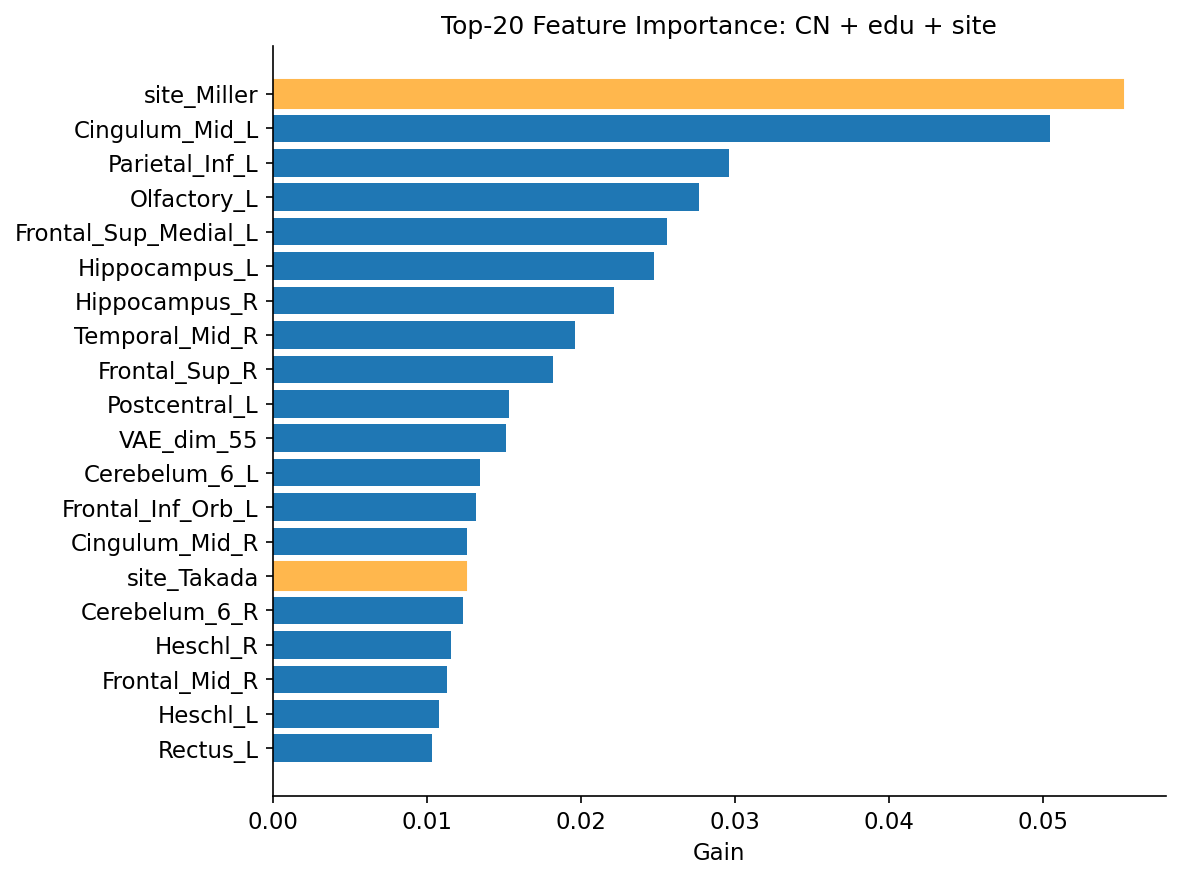

Demographic feature ranks:
  site_Miller: rank=1/189, gain=0.0552
  site_Takada: rank=15/189, gain=0.0125
  site_Behrens: rank=44/189, gain=0.0059
  site_Bruno: rank=56/189, gain=0.0044
  education: rank=163/189, gain=0.0018
  site_Matallana: rank=186/189, gain=0.0010
  site_Avila: rank=187/189, gain=0.0000
  site_Lopera: rank=188/189, gain=0.0000
  site_Slachevsky: rank=189/189, gain=0.0000


In [7]:
model_demo = XGBRegressor(**params_demo)
model_demo.fit(X_cn_demo, y_cn, verbose=False)

importances = model_demo.feature_importances_
feat_imp = sorted(zip(feat_names, importances), key=lambda x: x[1], reverse=True)

top20 = feat_imp[:20]
names, vals = zip(*top20)
display_names = [readable_feature_name(n) for n in names]

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(top20))
bars = ax.barh(y_pos, vals, align="center")

for i, (name, _) in enumerate(top20):
    if name == "education":
        bars[i].set_color("#EF5350")
    elif name.startswith("site_"):
        bars[i].set_color("#FFB74D")

ax.set_yticks(y_pos)
ax.set_yticklabels(display_names)
ax.invert_yaxis()
ax.set_xlabel("Gain")
ax.set_title("Top-20 Feature Importance: CN + edu + site")
plt.tight_layout()
plt.savefig(IMGDIR / "cn_demo_importance.png", bbox_inches="tight", dpi=300)
plt.show()

demo_feats = [(n, v) for n, v in feat_imp if n == "education" or n.startswith("site_")]
print("Demographic feature ranks:")
for n, v in demo_feats:
    rank = [x[0] for x in feat_imp].index(n) + 1
    print(f"  {n}: rank={rank}/{len(feat_imp)}, gain={v:.4f}")

## Summary

In [8]:
print("=" * 70)
print("CN-only + Demographics Experiment Summary")
print("=" * 70)
for config_name, group_results in results.items():
    print(f"\n{config_name}:")
    for group, metrics in group_results.items():
        print(f"  {group:10s}: n={metrics['n']:4d}, MAE={metrics['mae']:.2f}, "
              f"R²={metrics['r2']:.3f}, Gap={metrics['gap']:+.2f}")

CN-only + Demographics Experiment Summary

CN baseline (no demo):
  CN_test   : n=  53, MAE=6.09, R²=0.487, Gap=-0.07
  AD        : n= 422, MAE=6.97, R²=-0.113, Gap=+0.21
  FTD       : n= 297, MAE=7.42, R²=-0.335, Gap=+4.01

CN + educación + sitio:
  CN_test   : n=  37, MAE=5.51, R²=0.569, Gap=+0.41
  AD        : n= 348, MAE=6.41, R²=0.054, Gap=+0.70
  FTD       : n= 211, MAE=6.49, R²=-0.071, Gap=+4.11
